# Dev / Test Notebook — Blockchain Adoption Readiness Assessment

This notebook is for **developing and testing the core logic** (Fuzzy Engine +
LLM Explanation) cell-by-cell, the same way you'd test logic in an NLP/pattern
recognition assignment — it is NOT for "training a model" (there is no model
being trained here; Fuzzy AHP-TOPSIS is a deterministic calculation, not a
learned model).

Use this notebook to:
- Test `fuzzy_engine.py` logic with different sample answers
- Inspect intermediate values (weights, scores, diagnostic flags)
- Test different LLM prompt designs before changing `llm_explainer.py`
- Run sensitivity analysis and inspect results visually

The actual app (`app.py`) imports the same modules used here — so anything
you validate in this notebook is exactly what powers the Streamlit app.

**Setup:** make sure you've run `pip install -r requirements.txt` and created
your `.env` file (see `.env.example`) before running the LLM cells below.

## Setup

In [1]:
import sys
sys.path.insert(0, ".")  # ensure local modules are importable

from questions import STAGE1_QUESTIONS, STAGE2_QUESTIONS, VALID_STAGE2_OPTIONS, DIM_ORDER
from fuzzy_engine import (
    get_default_weights, evaluate_stage1, evaluate_stage2,
    generate_diagnostic_flags, score_to_tier, sensitivity_analysis,
)
from llm_explainer import generate_llm_explanation, check_llm_faithfulness

import matplotlib.pyplot as plt
import numpy as np

print("Modules loaded successfully.")

Modules loaded successfully.


## Stage 1 — Test Suitability Screening

In [2]:
# 👇 EDIT YOUR TEST ANSWERS HERE
stage1_test_answers = {
    "Q1_multiple_decision_power": "Yes",
    "Q2_trust_third_party":       "No",
    "Q3_trust_majority":          "Yes",
    "Q4_equal_influence":         "Yes",
    "Q5_data_sharing_advantage":  "Yes",
    "Q6_aligned_interests":       "Yes",
    "Q7_misbehaving_opposed":     "Yes",
    "Q8_all_actors_involved":     "No",
    "Q9_actors_autonomous":       "Yes",
    "Q10_prevent_retroactive":    "Yes",
    "Q11_prevent_proactive":      "No",
}

stage1_result = evaluate_stage1(stage1_test_answers)
print(stage1_result["message"])
for k, v in stage1_result.items():
    print(f"  {k}: {v}")

Your business context appears structurally suitable for blockchain consideration.
  yes_count: 8
  total_questions: 11
  ratio: 0.727
  gate_decision: PROCEED
  message: Your business context appears structurally suitable for blockchain consideration.


## Stage 2 — Test Readiness Assessment

In [3]:
# 👇 EDIT YOUR TEST ANSWERS HERE (must be one of VALID_STAGE2_OPTIONS)
stage2_test_answers = {
    "Q12_management_support":     "High",
    "Q13_staff_resistance":       "Moderate",
    "Q14_infrastructure_compat":  "Moderate",
    "Q15_integration_complexity": "Low",
    "Q16_cost_tolerance":         "Low",
    "Q17_roi_timeline":           "Moderate",
    "Q18_regulatory_clarity":     "Moderate",
    "Q19_compliance_risk":        "High",
}

weights = get_default_weights()
dim_scores, overall_score = evaluate_stage2(stage2_test_answers, weights)
tier = score_to_tier(overall_score)

print("Dimension Weights:", {k: round(v, 4) for k, v in weights.items()})
print("Dimension Scores:", {k: round(v, 4) for k, v in dim_scores.items()})
print(f"Overall Score: {overall_score:.4f}  ({overall_score*100:.2f} / 100)")
print(f"Tier: {tier}")

Dimension Weights: {'Economic': 0.4079, 'Organizational': 0.3056, 'Technological': 0.196, 'Regulatory': 0.0905}
Dimension Scores: {'Organizational': 0.6342, 'Technological': 0.3658, 'Economic': 0.3658, 'Regulatory': 0.6342}
Overall Score: 0.4721  (47.21 / 100)
Tier: Tier 2 — Emerging Readiness


## Diagnostic Flags

In [4]:
diagnostic_flags = generate_diagnostic_flags(dim_scores, weights)
for f in diagnostic_flags:
    print("-", f)

- Strongest dimension: Organizational (score=0.634)
- Weakest dimension: Technological (score=0.366)
- RULE: Economic is heavily weighted AND scored low — this is a primary barrier.
- RULE: Regulatory scored well but carries low weight — limited impact on overall readiness.
- RULE: Readiness is relatively balanced across all dimensions.


## Sensitivity Analysis (Robustness Check)

In [5]:
sensitivity_results = sensitivity_analysis(dim_scores, weights)
max_delta = max(abs(v - overall_score) for v in sensitivity_results.values())

print(f"Baseline score: {overall_score:.4f}")
for scenario, score in sensitivity_results.items():
    print(f"  {scenario}: {score}  (Δ={score-overall_score:+.4f})")
print(f"\nMax delta: {max_delta:.4f}  -> {'ROBUST' if max_delta <= 0.05 else 'SENSITIVE - review weights'}")

Baseline score: 0.4721
  Economic_increase_10pct: 0.4679  (Δ=-0.0042)
  Economic_decrease_10pct: 0.4766  (Δ=+0.0045)
  Organizational_increase_10pct: 0.4769  (Δ=+0.0048)
  Organizational_decrease_10pct: 0.467  (Δ=-0.0051)
  Technological_increase_10pct: 0.4701  (Δ=-0.0020)
  Technological_decrease_10pct: 0.4742  (Δ=+0.0021)
  Regulatory_increase_10pct: 0.4736  (Δ=+0.0015)
  Regulatory_decrease_10pct: 0.4706  (Δ=-0.0015)

Max delta: 0.0051  -> ROBUST


## Radar Chart (matplotlib — for quick visual testing only)

The Streamlit app itself uses Plotly, not matplotlib. This cell is just for quick visual sanity checks while developing.

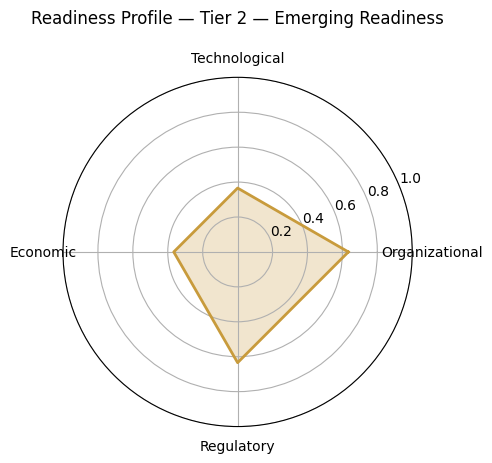

In [6]:
labels = list(dim_scores.keys())
values = list(dim_scores.values())
values += values[:1]
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))
ax.plot(angles, values, linewidth=2, color="#C89B3C")
ax.fill(angles, values, alpha=0.25, color="#C89B3C")
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title(f"Readiness Profile — {tier}", fontsize=12, pad=20)
plt.tight_layout()
plt.show()

## Stage 3 — Test LLM Explanation

⚠️ Running this cell calls the OpenAI API and uses a small number of tokens.
Make sure your `.env` file has a valid `OPENAI_API_KEY` before running.

In [7]:
explanation = generate_llm_explanation(dim_scores, weights, tier, overall_score, diagnostic_flags)
print(explanation)

Your assessment results indicate that your business is in the "Emerging Readiness" tier for adopting blockchain technology, with an overall readiness score of 47.2 out of 100. This suggests that while you have some foundational elements in place, there are important areas that need attention to fully embrace this technology.

The strongest aspect of your readiness is your organizational dimension, which scored 0.634. This indicates that your internal structures and processes are relatively well-prepared for blockchain adoption. However, the technological dimension is your weakest area, scoring only 0.366. This suggests that you may need to enhance your technological capabilities to successfully implement blockchain solutions.

Additionally, the economic dimension is a significant barrier, as it scored low despite its high importance. This means that financial considerations may pose challenges to your readiness. On a positive note, your regulatory score is decent, but since it carries 

## Faithfulness Check

Verifies the LLM explanation actually references the dimensions flagged as important — a lightweight check against hallucination.

In [8]:
faithfulness = check_llm_faithfulness(explanation, diagnostic_flags)
for k, v in faithfulness.items():
    print(f"{k}: {v}")

key_terms_from_flags: ['Organizational', 'Technological', 'Economic', 'Regulatory']
found_in_explanation: ['Organizational', 'Technological', 'Economic', 'Regulatory']
missing_from_explanation: []
coverage_ratio: 1.0
faithfulness_status: PASS


## Experiment Freely

Use the cells below to try different answer combinations, tweak prompt
wording in `llm_explainer.py`, or test edge cases (e.g. all "Very Low"
answers, all "Very High" answers) before changing the main app.

In [9]:
# Test extreme scenarios: all answers are Very Low
test_very_low = {
    "Q12_management_support":     "Very Low",
    "Q13_staff_resistance":       "Very Low",
    "Q14_infrastructure_compat":  "Very Low",
    "Q15_integration_complexity": "Very Low",
    "Q16_cost_tolerance":         "Very Low",
    "Q17_roi_timeline":           "Very Low",
    "Q18_regulatory_clarity":     "Very Low",
    "Q19_compliance_risk":        "Very Low",
}

dim_scores_low, overall_low = evaluate_stage2(test_very_low, weights)
print("=== All Very Low ===")
print("Dimension Scores:", {k: round(v,3) for k,v in dim_scores_low.items()})
print("Overall Score:", round(overall_low, 4))
print("Tier:", score_to_tier(overall_low))


=== All Very Low ===
Dimension Scores: {'Organizational': 0.0, 'Technological': 0.0, 'Economic': 0.0, 'Regulatory': 0.0}
Overall Score: 0.0
Tier: Tier 1 — Not Ready


In [10]:
test_very_high = {k: "Very High" for k in stage2_test_answers.keys()}

dim_scores_high, overall_high = evaluate_stage2(test_very_high, weights)
print("=== All Very High ===")
print("Dimension Scores:", {k: round(v,3) for k,v in dim_scores_high.items()})
print("Overall Score:", round(overall_high, 4))
print("Tier:", score_to_tier(overall_high))

=== All Very High ===
Dimension Scores: {'Organizational': 1.0, 'Technological': 1.0, 'Economic': 1.0, 'Regulatory': 1.0}
Overall Score: 1.0
Tier: Tier 4 — Highly Ready


In [11]:
scenarios = {
    "All Very Low":  {k: "Very Low" for k in stage2_test_answers.keys()},
    "Mixed (Original Test)": stage2_test_answers,
    "All Very High": {k: "Very High" for k in stage2_test_answers.keys()},
}

print(f"{'Scenario':<20} {'Overall Score':<15} {'Tier'}")
for name, answers in scenarios.items():
    _, overall = evaluate_stage2(answers, weights)
    tier = score_to_tier(overall)
    print(f"{name:<20} {overall:<15.4f} {tier}")

Scenario             Overall Score   Tier
All Very Low         0.0000          Tier 1 — Not Ready
Mixed (Original Test) 0.4721          Tier 2 — Emerging Readiness
All Very High        1.0000          Tier 4 — Highly Ready


In [12]:
from llm_explainer import get_client

def test_custom_prompt(dim_scores, weights, tier, overall_score, flags, custom_instruction):
    """Quickly test different prompt instructions without modifying llm_explainer.py itself"""
    from questions import DIM_ORDER
    dim_lines = "\n".join(f"- {dim}: score={round(dim_scores[dim],3)}" for dim in DIM_ORDER)
    rule_lines = "\n".join(f"- {f}" for f in flags)

    prompt = f"""{custom_instruction}

Overall Score: {round(overall_score*100,1)}/100
Tier: {tier}
Dimension Scores:
{dim_lines}
Diagnostic Flags:
{rule_lines}
"""
    client = get_client()
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=200,
        temperature=0.4,
    )
    return response.choices[0].message.content

# Test a more concise version
short_explanation = test_custom_prompt(
    dim_scores, weights, tier, overall_score, diagnostic_flags,
    custom_instruction="Explain this in ONE short sentence, for a busy business owner."
)
print(short_explanation)

Your business is moderately ready for challenges, with strong organizational capabilities but significant economic and technological weaknesses that need addressing.
